In [23]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import ast

import jax
import jax.numpy as jnp
from jax import Array

import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator
import seaborn as sns

sns.set_theme()

# Main table

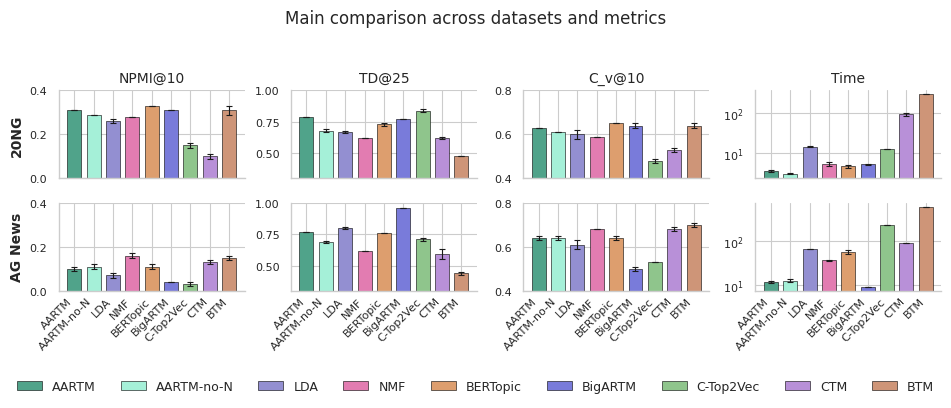

In [43]:
# Dataset, Model, NPMI mean, NPMI std, TD mean, TD std, C_v mean, C_v std, F1 mean, F1 std, Time mean, Time std
data = (
    [
        ("20NG", "AARTM",
            0.31, 0.00, 0.79, 0.00,
            0.63, 0.00, 0.88, 0.00,
            3.61, 0.25),

        ("20NG", "AARTM-no-N",
            0.29, 0.00, 0.68, 0.01,
            0.61, 0.00, 0.88, 0.00,
            3.12, 0.16),

        ("20NG", "BERTopic",
            0.33, 0.00, 0.73, 0.01,
            0.65, 0.00, 0.88, 0.00,
            4.74, 0.37),

        ("20NG", "BigARTM",
            0.31, 0.00, 0.77, 0.00,
            0.64, 0.01, 0.88, 0.00,
            5.23, 0.01),

        ("20NG", "C-Top2Vec",
            0.15, 0.01, 0.84, 0.01,
            0.48, 0.01, 0.87, 0.00,
            12.72, 0.11),

        ("20NG", "LDA",
            0.26, 0.01, 0.67, 0.01,
            0.60, 0.02, 0.88, 0.00,
            14.63, 0.76),

        ("20NG", "NMF",
            0.28, 0.00, 0.62, 0.00,
            0.59, 0.00, 0.87, 0.00,
            5.50, 0.68),

        ("20NG", "BTM",
            0.31, 0.02, 0.48, 0.00,
            0.64, 0.01, 0.88, 0.00,
            290.48, 0.47),

        ("20NG", "CTM",
            0.10, 0.01, 0.62, 0.01,
            0.53, 0.01, 0.86, 0.00,
            93.21, 9.36),
    ] + [
        ("AG News", "AARTM",
            0.10, 0.01, 0.77, 0.00,
            0.64, 0.01, 0.87, 0.00,
            11.42, 0.57),

        ("AG News", "AARTM-no-N",
            0.11, 0.01, 0.69, 0.01,
            0.64, 0.01, 0.87, 0.01,
            12.31, 0.98),

        ("AG News", "BERTopic",
            0.11, 0.01, 0.76, 0.00,
            0.64, 0.01, 0.86, 0.00,
            55.85, 5.31),

        ("AG News", "LDA",
            0.07, 0.01, 0.80, 0.01,
            0.61, 0.02, 0.87, 0.00,
            67.06, 0.45),

        ("AG News", "NMF",
            0.16, 0.01, 0.62, 0.00,
            0.68, 0.00, 0.86, 0.00,
            36.40, 0.56),

        ("AG News", "BigARTM",
            0.04, 0.00, 0.96, 0.00,
            0.50, 0.01, 0.87, 0.00,
            9.04, 0.06),

        ("AG News", "C-Top2Vec",
            0.03, 0.01, 0.71, 0.01,
            0.53, 0.00, 0.87, 0.00,
            230.56, 3.17),

        ("AG News", "CTM",
            0.13, 0.01, 0.59, 0.04,
            0.68, 0.01, 0.87, 0.00,
            90.69, 1.77),

        ("AG News", "BTM",
            0.15, 0.01, 0.44, 0.01,
            0.70, 0.01, 0.87, 0.01,
            602.50, 3.56),
    ] + [
        # ("DBpedia14", "AARTM",       0.00, 0.01, 0.82, 0.01, 0.93, 0.01, 0.93, 0.01,   98.9,   0.8),
        # ("DBpedia14", "AARTM-no-N", -0.01, 0.01, 0.75, 0.01, 0.93, 0.01, 0.93, 0.01,   74.9,   1.0),
        # ("DBpedia14", "LDA",        -0.05, 0.01, 0.77, 0.01, 0.91, 0.01, 0.91, 0.01,  369.7,   3.8),
        # ("DBpedia14", "NMF",         0.01, 0.01, 0.61, 0.01, 0.93, 0.01, 0.93, 0.01,  202.1,   0.9),
        # ("DBpedia14", "BERTopic",   -0.02, 0.02, 0.68, 0.01, 0.79, 0.02, 0.79, 0.02,  364.3,   4.8),
    ]
)

columns = [
    "Dataset", "Model",
    "NPMI@10_mean", "NPMI@10_std",
    "TD@25_mean", "TD@25_std",
    "C_v@10_mean", "C_v@10_std",
    "Macro-F1_mean", "Macro-F1_std",
    "Time_mean", "Time_std",
]

df = pd.DataFrame(data, columns=columns)


# -----------------------------
# 2. Convert to long format
# -----------------------------

metrics = ["NPMI@10", "TD@25", "C_v@10", "Macro-F1", "Time"]

long_rows = []

for _, row in df.iterrows():
    for metric in metrics:
        mean_col = f"{metric}_mean" if metric != "Time" else "Time_mean"
        std_col = f"{metric}_std" if metric != "Time" else "Time_std"

        long_rows.append({
            "Dataset": row["Dataset"],
            "Model": row["Model"],
            "Metric": metric,
            "Mean": row[mean_col],
            "Std": row[std_col],
        })

plot_df = pd.DataFrame(long_rows)


# -----------------------------
# 3. Plot style
# -----------------------------
sns.set_theme(
    style="whitegrid",
    context="paper",
    font_scale=1.0,
)

model_order = ["AARTM", "AARTM-no-N", "LDA", "NMF", "BERTopic", "BigARTM", "C-Top2Vec", "CTM", "BTM"]
dataset_order = ["20NG", "AG News"]
metric_order = ["NPMI@10", "TD@25", "C_v@10", "Time"]

palette = {
    "AARTM": "#50a38a",
    "AARTM-no-N": "#a5f0d8",
    "LDA": "#938fd1",
    "NMF": "#e27cb1",
    "BERTopic": "#dd9e6e",
    "BigARTM": "#797BDA",
    "C-Top2Vec": "#8FC58C",
    "CTM": "#B890D8",
    "BTM": "#CE9578",
}

def plot_table2_matrix(
    plot_df,
    metric_order=metric_order,
    dataset_order=dataset_order,
    model_order=model_order,
    palette=palette,
    save_path="table2_bar_matrix.pdf",
):
    n_rows = len(dataset_order)
    n_cols = len(metric_order)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(2.4 * n_cols, 1.9 * n_rows),
        sharex=False,
        sharey=False,
        constrained_layout=False,
    )

    if n_rows == 1:
        axes = np.expand_dims(axes, axis=0)
    if n_cols == 1:
        axes = np.expand_dims(axes, axis=1)

    x = np.arange(len(model_order))
    bar_width = 0.72

    for i, dataset in enumerate(dataset_order):
        for j, metric in enumerate(metric_order):
            ax = axes[i, j]

            sub = plot_df[
                (plot_df["Dataset"] == dataset) &
                (plot_df["Metric"] == metric)
            ].copy()

            sub["Model"] = pd.Categorical(
                sub["Model"],
                categories=model_order,
                ordered=True,
            )
            sub = sub.sort_values("Model")

            means = sub["Mean"].values
            stds = sub["Std"].values
            colors = [palette[m] for m in sub["Model"].astype(str).values]

            ax.bar(
                x,
                means,
                yerr=stds,
                width=bar_width,
                color=colors,
                edgecolor="black",
                linewidth=0.4,
                error_kw={
                    "elinewidth": 0.8,
                    "capsize": 2,
                    "capthick": 0.8,
                },
            )

            # Zero line for NPMI because DBpedia has negative values
            if metric == "NPMI@10":
                ax.axhline(0.0, color="black", linewidth=0.6)

            # Titles and labels
            if i == 0:
                ax.set_title(metric, fontsize=10, pad=6)

            if j == 0:
                ax.set_ylabel(dataset, fontsize=10, fontweight="bold")
            else:
                ax.set_ylabel("")

            # X tick labels only on bottom row
            ax.set_xticks(x)
            if i == n_rows - 1:
                ax.set_xticklabels(model_order, rotation=45, ha="right", fontsize=8)
            else:
                ax.set_xticklabels([])

            # Compact y-axis formatting
            ax.tick_params(axis="y", labelsize=8)
            ax.tick_params(axis="x", length=0)

            # Metric-specific y limits for cleaner visual comparison
            if metric == "TD@25":
                ax.set_ylim(0.3, 1.0)
            elif metric == "C_v@10":
                ax.set_ylim(0.4, 0.8)
            elif metric == "Macro-F1":
                ax.set_ylim(0.85, 0.9)
            elif metric == "NPMI@10":
                ax.set_ylim(0.0, 0.4)
            elif metric == "Time":
                # ax.set_ylim(0, max(means + stds) * 1.15)
                ax.set_yscale("log")
                pass

            # Remove unnecessary spines
            sns.despine(ax=ax)

    handles = [
        plt.Rectangle(
            (0, 0),
            1,
            1,
            color=palette[m],
            ec="black",
            linewidth=0.4,
            label=m,
        )
        for m in model_order
    ]

    fig.legend(
        handles=handles,
        labels=model_order,
        loc="lower center",
        ncol=len(model_order),
        frameon=False,
        bbox_to_anchor=(0.5, -0.02),
        fontsize=9,
    )

    fig.suptitle(
        "Main comparison across datasets and metrics",
        fontsize=12,
        y=1.02,
    )
    plt.tight_layout(rect=[0, 0.08, 1, 0.98])

    fig.savefig(save_path, bbox_inches="tight", dpi=300)
    fig.savefig(save_path.replace(".pdf", ".png"), bbox_inches="tight", dpi=300)

    return fig, axes


fig, axes = plot_table2_matrix(plot_df)
plt.show()

# Gamma ablation

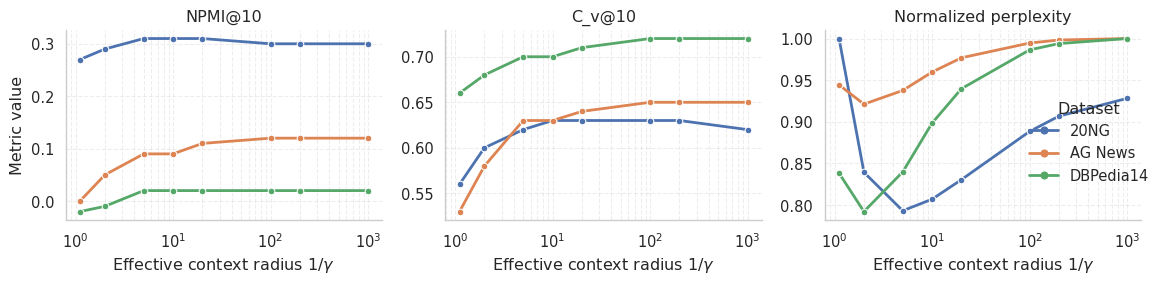

In [77]:
rows = [
    # dataset, C, gamma, npmi, td, c_v, f1, perplexity
    ("20NG", 1000, 0.001,  0.30, 0.78, 0.62, 0.61, 2072.80),
    ("20NG", 1000, 0.005,  0.30, 0.78, 0.63, 0.61, 2025.15),
    ("20NG", 1000, 0.01,   0.30, 0.79, 0.63, 0.60, 1984.15),
    ("20NG", 1000, 0.05,   0.31, 0.79, 0.63, 0.60, 1854.92),
    ("20NG", 1000, 0.1,    0.31, 0.79, 0.63, 0.59, 1802.48),
    ("20NG", 1000, 0.2,    0.31, 0.76, 0.62, 0.56, 1771.53),
    ("20NG", 1000, 0.5,    0.29, 0.74, 0.60, 0.55, 1874.63),
    ("20NG", 1000, 0.9,    0.27, 0.72, 0.56, 0.52, 2233.21),

    ("AG News", 1000, 0.001,  0.12, 0.76, 0.65, 0.87, 1108.96),
    ("AG News", 1000, 0.005,  0.12, 0.76, 0.65, 0.87, 1107.02),
    ("AG News", 1000, 0.01,   0.12, 0.76, 0.65, 0.87, 1102.98),
    ("AG News", 1000, 0.05,   0.11, 0.76, 0.64, 0.87, 1083.31),
    ("AG News", 1000, 0.1,    0.09, 0.76, 0.63, 0.87, 1064.35),
    ("AG News", 1000, 0.2,    0.09, 0.75, 0.63, 0.87, 1039.85),
    ("AG News", 1000, 0.5,    0.05, 0.74, 0.58, 0.87, 1021.58),
    ("AG News", 1000, 0.9,    0.00, 0.73, 0.53, 0.85, 1047.27),

    ("DBPedia14", 1000, 0.001,  0.02, 0.80, 0.72, 0.92, 676.02),
    ("DBPedia14", 1000, 0.005,  0.02, 0.80, 0.72, 0.92, 671.93),
    ("DBPedia14", 1000, 0.01,   0.02, 0.80, 0.72, 0.92, 666.81),
    ("DBPedia14", 1000, 0.05,   0.02, 0.80, 0.71, 0.92, 635.31),
    ("DBPedia14", 1000, 0.1,    0.02, 0.81, 0.70, 0.92, 607.39),
    ("DBPedia14", 1000, 0.2,    0.02, 0.79, 0.70, 0.92, 567.78),
    ("DBPedia14", 1000, 0.5,   -0.01, 0.76, 0.68, 0.93, 535.60),
    ("DBPedia14", 1000, 0.9,   -0.02, 0.71, 0.66, 0.92, 566.76),
]

df = pd.DataFrame(
    rows,
    columns=["dataset", "C", "gamma", "NPMI@10", "TD@25", "C_v@10", "Macro-F1", "Perplexity"]
)
df["Normalized perplexity"] = (
    df.groupby("dataset")["Perplexity"]
      .transform(lambda x: x / x.max())
)

# -----------------------------
# 2. Compute effective radius
# -----------------------------
df["inverse_gamma"] = 1.0 / df["gamma"]
df["effective_radius"] = np.minimum(df["C"], df["inverse_gamma"])

# Optional: round effective radius to avoid floating-point noise
df["effective_radius"] = df["effective_radius"].round(3)

# -----------------------------
# 3. Aggregate duplicated settings
# -----------------------------
# Several (C, gamma) combinations lead to the same effective radius.
# We average them to show the main trend.
metrics = ["NPMI@10", "C_v@10", "Normalized perplexity"]

agg = (
    df.groupby(["dataset", "effective_radius"], as_index=False)[metrics]
      .mean()
)

# Convert to long format for seaborn
plot_df = agg.melt(
    id_vars=["dataset", "effective_radius"],
    value_vars=metrics,
    var_name="metric",
    value_name="value"
)

# -----------------------------
# 4. Plot
# -----------------------------
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

g = sns.relplot(
    data=plot_df,
    x="effective_radius",
    y="value",
    hue="dataset",
    col="metric",
    kind="line",
    marker="o",
    facet_kws={"sharey": False},
    height=3.0,
    aspect=1.15,
    linewidth=2.0
)

# Use log scale because context radius changes multiplicatively: 1, 10, 100, 1000
for i, ax in enumerate(g.axes.flat):
    ax.set_xscale("log")
    ax.set_xlabel(r"Effective context radius $1/\gamma$")
    ax.grid(True, which="both", linestyle="--", alpha=0.35)
    # if i == 2:
    #     ax.set_yscale()

g.set_titles("{col_name}")
g.set_ylabels("Metric value")

# Improve legend
g._legend.set_title("Dataset")

plt.tight_layout()
plt.savefig("table3_effective_context_radius.pdf", bbox_inches="tight")
plt.savefig("table3_effective_context_radius.png", dpi=300, bbox_inches="tight")
plt.show()

# Self-aware

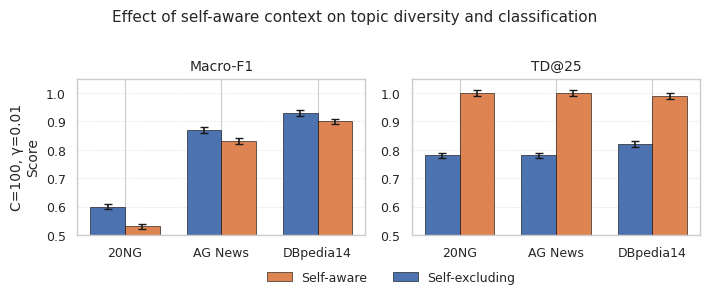

In [ ]:
rows = [
    # dataset, C, gamma, self_aware, npmi_mean, npmi_std, td_mean, td_std, acc_mean, acc_std, f1_mean, f1_std

    # 20NG
    ("20NG", 10,   0.1,  False, 0.27, 0.01, 0.75, 0.01, 0.61, 0.01, 0.58, 0.01),
    ("20NG", 10,   0.1,  True,  0.20, 0.01, 1.00, 0.01, 0.39, 0.01, 0.35, 0.01),
    ("20NG", 100,  0.01, False, 0.28, 0.01, 0.78, 0.01, 0.63, 0.01, 0.60, 0.01),
    ("20NG", 100,  0.01, True,  0.26, 0.01, 1.00, 0.01, 0.56, 0.01, 0.53, 0.01),

    # AG News
    ("AG News", 10,   0.1,  False, 0.07, 0.01, 0.76, 0.01, 0.87, 0.01, 0.87, 0.01),
    ("AG News", 10,   0.1,  True, -0.04, 0.01, 1.00, 0.01, 0.79, 0.01, 0.79, 0.01),
    ("AG News", 100,  0.01, False, 0.08, 0.01, 0.78, 0.01, 0.87, 0.01, 0.87, 0.01),
    ("AG News", 100,  0.01, True,  0.01, 0.01, 1.00, 0.01, 0.83, 0.01, 0.83, 0.01),

    # DBpedia14
    ("DBpedia14", 10,   0.1,  False, 0.01, 0.01, 0.80, 0.01, 0.93, 0.01, 0.93, 0.01),
    ("DBpedia14", 10,   0.1,  True, -0.02, 0.01, 1.00, 0.01, 0.86, 0.01, 0.86, 0.01),
    ("DBpedia14", 100,  0.01, False, 0.00, 0.01, 0.82, 0.01, 0.93, 0.01, 0.93, 0.01),
    ("DBpedia14", 100,  0.01, True,  0.01, 0.01, 0.99, 0.01, 0.90, 0.01, 0.90, 0.01),
]

df = pd.DataFrame(
    rows,
    columns=[
        "dataset", "C", "gamma", "self_aware",
        "npmi_mean", "npmi_std",
        "td_mean", "td_std",
        "acc_mean", "acc_std",
        "f1_mean", "f1_std",
    ],
)

# -----------------------------
# Choose which settings to plot
# -----------------------------
# Recommended compact version:
# use only the two meaningful settings:
#   1. narrow context: C=10, gamma=0.1
#   2. default/effective-long context: C=100, gamma=0.01
#
# I would NOT show C=1000, gamma=0.01 in the main paper,
# because it is nearly redundant with C=100, gamma=0.01.
settings_to_plot = [
    # (10, 0.1),
    (100, 0.01),
]

# If you want the most compact version for the main paper, use only:
# settings_to_plot = [(100, 0.01)]

metrics = [
    ("f1", "Macro-F1"),
    ("td", "TD@25"),
]

datasets = ["20NG", "AG News", "DBpedia14"]

label_map = {
    False: "Self-excluding",
    True: "Self-aware",
}

color_map = {
    False: "#4C72B0",  # blue
    True: "#DD8452",   # orange
}

# -----------------------------
# Plot
# -----------------------------
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

n_rows = len(settings_to_plot)
n_cols = len(metrics)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(7.2, 2.6 * n_rows),
    sharey=False,
)

if n_rows == 1:
    axes = np.array([axes])

bar_width = 0.36
x = np.arange(len(datasets))

for row_idx, (C, gamma) in enumerate(settings_to_plot):
    sub = df[(df["C"] == C) & (df["gamma"] == gamma)]

    for col_idx, (metric_key, metric_label) in enumerate(metrics):
        ax = axes[row_idx, col_idx]

        for j, self_aware in enumerate([False, True]):
            vals = []
            errs = []

            for dataset in datasets:
                item = sub[
                    (sub["dataset"] == dataset)
                    & (sub["self_aware"] == self_aware)
                ]
                if len(item) != 1:
                    raise ValueError(
                        f"Missing or duplicated row for "
                        f"dataset={dataset}, C={C}, gamma={gamma}, "
                        f"self_aware={self_aware}"
                    )

                vals.append(item[f"{metric_key}_mean"].iloc[0])
                errs.append(item[f"{metric_key}_std"].iloc[0])

            offset = (j - 0.5) * bar_width

            ax.bar(
                x + offset,
                vals,
                width=bar_width,
                yerr=errs,
                capsize=3,
                label=label_map[self_aware],
                color=color_map[self_aware],
                edgecolor="black",
                linewidth=0.4,
            )

        ax.set_xticks(x)
        ax.set_xticklabels(datasets)
        ax.set_ylim(0.0, 1.05)
        ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)

        if row_idx == 0:
            ax.set_title(metric_label)

        if col_idx == 0:
            ax.set_ylabel(f"C={C}, γ={gamma}\nScore")
        ax.set_ylim([0.5, 1.05])

        # if row_idx == 0 and col_idx == n_cols - 1:
        #     ax.legend(frameon=False, loc="lower right")

fig.suptitle(
    "Effect of self-aware context on topic diversity and classification",
    y=1.02,
    fontsize=11,
)

handles = [
    plt.Rectangle(
        (0, 0),
        1,
        1,
        color=color_map[m],
        ec="black",
        linewidth=0.4,
        label=m,
    )
    for m in [True, False]
]

fig.legend(
    handles=handles,
    labels=[label_map[m] for m in [True, False]],
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.55, -0.08),
    fontsize=9,
)

fig.tight_layout()

plt.savefig("self_aware_context_ablation.pdf", bbox_inches="tight")
plt.savefig("self_aware_context_ablation.png", dpi=300, bbox_inches="tight")
plt.show()

# Attention passes

In [ ]:
rows = [
    # dataset, C, gamma, self_aware, npmi_mean, npmi_std, td_mean, td_std, acc_mean, acc_std, f1_mean, f1_std

    # 20NG
    ("20NG", 10,   0.1,  False, 0.27, 0.01, 0.75, 0.01, 0.61, 0.01, 0.58, 0.01),
    ("20NG", 10,   0.1,  True,  0.20, 0.01, 1.00, 0.01, 0.39, 0.01, 0.35, 0.01),
    ("20NG", 100,  0.01, False, 0.28, 0.01, 0.78, 0.01, 0.63, 0.01, 0.60, 0.01),
    ("20NG", 100,  0.01, True,  0.26, 0.01, 1.00, 0.01, 0.56, 0.01, 0.53, 0.01),

    # AG News
    ("AG News", 10,   0.1,  False, 0.07, 0.01, 0.76, 0.01, 0.87, 0.01, 0.87, 0.01),
    ("AG News", 10,   0.1,  True, -0.04, 0.01, 1.00, 0.01, 0.79, 0.01, 0.79, 0.01),
    ("AG News", 100,  0.01, False, 0.08, 0.01, 0.78, 0.01, 0.87, 0.01, 0.87, 0.01),
    ("AG News", 100,  0.01, True,  0.01, 0.01, 1.00, 0.01, 0.83, 0.01, 0.83, 0.01),

    # DBpedia14
    ("DBpedia14", 10,   0.1,  False, 0.01, 0.01, 0.80, 0.01, 0.93, 0.01, 0.93, 0.01),
    ("DBpedia14", 10,   0.1,  True, -0.02, 0.01, 1.00, 0.01, 0.86, 0.01, 0.86, 0.01),
    ("DBpedia14", 100,  0.01, False, 0.00, 0.01, 0.82, 0.01, 0.93, 0.01, 0.93, 0.01),
    ("DBpedia14", 100,  0.01, True,  0.01, 0.01, 0.99, 0.01, 0.90, 0.01, 0.90, 0.01),
]

df = pd.DataFrame(
    rows,
    columns=[
        "dataset", "C", "L", "gamma", "self_aware",
        "npmi_mean", "npmi_std",
        "td_mean", "td_std",
        "acc_mean", "acc_std",
        "f1_mean", "f1_std",
    ],
)


def plot_attention_passes(
    df,
    dataset,
    output_path=None,
    metrics=None,
    context_values=None,
    figsize=(10, 3.2),
):
    """
    Plot metric dependence on number of attention passes L.

    Expected columns:
        dataset, C, L,
        npmi_mean, npmi_std,
        td_mean, td_std,
        acc_mean, acc_std,
        f1_mean, f1_std

    Parameters
    ----------
    df : pd.DataFrame
        Results dataframe.
    dataset : str
        Dataset name to plot, e.g. "20NG", "AG News", "DBpedia14".
    output_path : str or Path, optional
        If given, saves the figure.
    metrics : list of tuples, optional
        Each tuple: (mean_col, std_col, display_name).
    context_values : list, optional
        Which context radii C to include.
    figsize : tuple
        Figure size.
    """

    if metrics is None:
        metrics = [
            ("f1_mean", "f1_std", "Macro-F1"),
            ("td_mean", "td_std", "TD@25"),
            ("npmi_mean", "npmi_std", "NPMI@10"),
        ]

    sub = df[df["dataset"] == dataset].copy()

    if context_values is not None:
        sub = sub[sub["C"].isin(context_values)]

    sub = sub.sort_values(["C", "L"])

    sns.set_theme(style="whitegrid", context="paper", font_scale=1.15)

    fig, axes = plt.subplots(
        1,
        len(metrics),
        figsize=figsize,
        sharex=True,
        constrained_layout=True,
    )

    if len(metrics) == 1:
        axes = [axes]

    palette = sns.color_palette("tab10", n_colors=sub["C"].nunique())

    for ax, (mean_col, std_col, label) in zip(axes, metrics):
        for color, (C, group) in zip(palette, sub.groupby("C")):
            x = group["L"].to_numpy()
            y = group[mean_col].to_numpy()
            yerr = group[std_col].to_numpy()

            ax.plot(
                x,
                y,
                marker="o",
                linewidth=2,
                markersize=4,
                color=color,
                label=f"$C={C}$",
            )

            ax.fill_between(
                x,
                y - yerr,
                y + yerr,
                color=color,
                alpha=0.15,
                linewidth=0,
            )

        ax.set_title(label)
        ax.set_xlabel("Attention passes $L$")
        ax.set_xticks(sorted(sub["L"].unique()))
        ax.grid(True, alpha=0.35)

    axes[0].set_ylabel("Metric value")

    # Put legend only once
    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        title="Context radius",
        loc="upper center",
        bbox_to_anchor=(0.5, 1.12),
        ncol=min(len(labels), 4),
        frameon=False,
    )

    fig.suptitle(f"Effect of multiple attention passes on {dataset}", y=1.28)

    if output_path is not None:
        fig.savefig(output_path, dpi=300, bbox_inches="tight")
        fig.savefig(output_path.with_suffix(".pdf"), bbox_inches="tight")

    return fig, axes


plot_attention_passes(
    df,
    dataset="20NG",
    output_path="figures/attention_passes_20ng.png",
    context_values=[2, 5, 10, 20],
)
plt.show()

# Benchmark

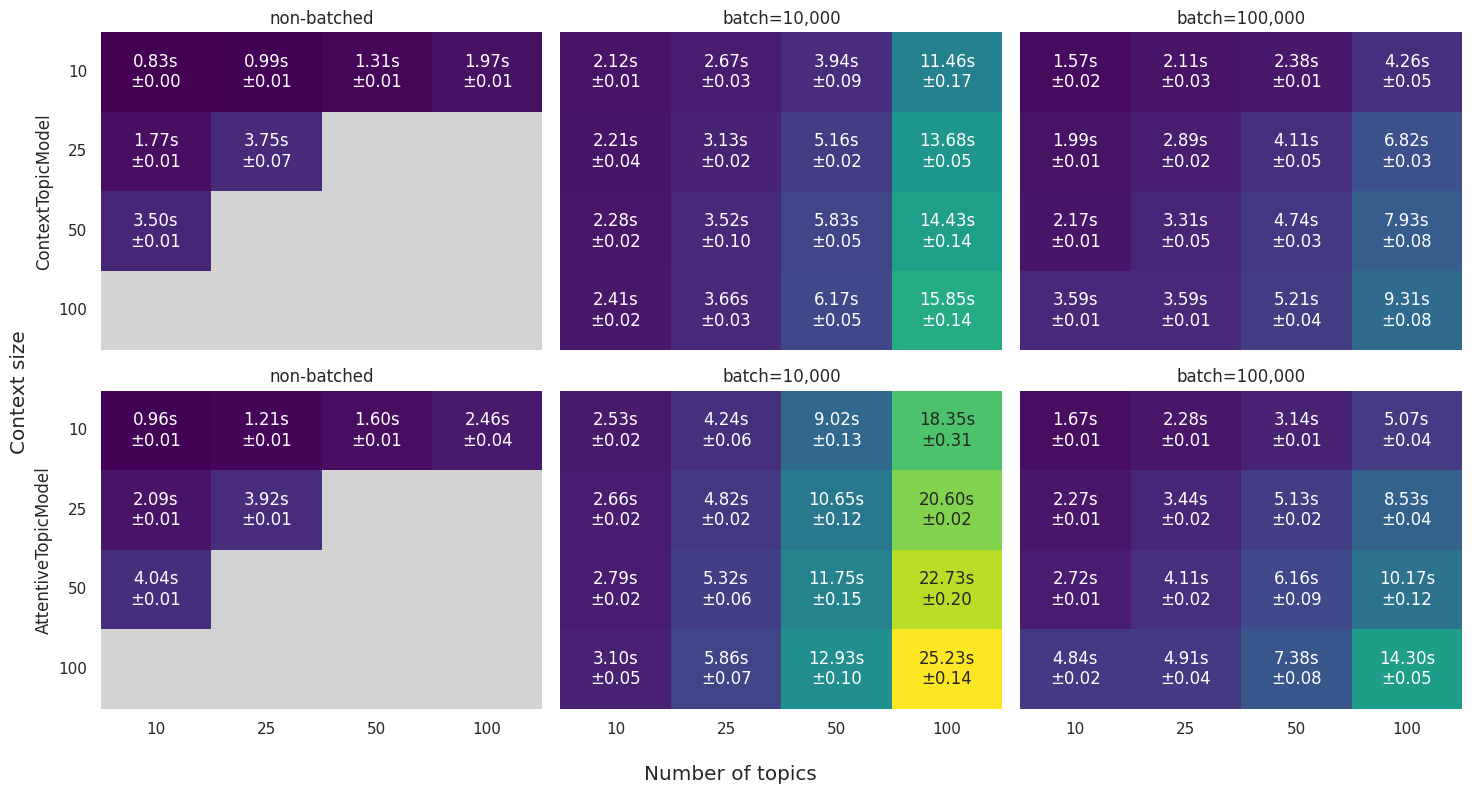

In [133]:
from matplotlib.cm import viridis


fig, ax = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)

vmin = benchmark_df["steady_mean_sec"].min()
vmax = benchmark_df["steady_mean_sec"].max()

cmap = viridis.copy()
cmap.set_bad(color="lightgray")

for i, model_type in enumerate(["ContextTopicModel", "AttentiveTopicModel"]):
    for j, batch_size in enumerate([None, 10_000, 100_000]):
        model_mask = benchmark_df.model == model_type
        if batch_size is None:
            batch_mask = (
                (benchmark_df.batched == False)
                & (benchmark_df.batch_size == 10_000)
            )
        else:
            batch_mask = (
                (benchmark_df.batch_size == batch_size)
                & benchmark_df.batched
            )
        records = benchmark_df[model_mask & batch_mask].copy()

        mean_pivot = records.pivot(
            index="ctx_len",
            columns="n_topics",
            values="steady_mean_sec",
        )
        std_pivot = records.pivot(
            index="ctx_len",
            columns="n_topics",
            values="steady_std",
        )
        if 100 not in mean_pivot.index:
            mean_pivot.loc[100] = [np.nan, np.nan, np.nan, np.nan]
            std_pivot.loc[100] = [np.nan, np.nan, np.nan, np.nan]

        def prepare_label(m, s):
            if np.isnan(m):
                return "NaN"
            return f"{m:.2f}s\n±{s:.2f}"

        labels = np.vectorize(prepare_label)(
            mean_pivot.values,
            std_pivot.reindex_like(mean_pivot).values
        )
        sns.heatmap(
            mean_pivot,
            mask=mean_pivot.isna(),
            cmap=cmap,
            annot=labels,
            fmt="",
            vmin=vmin,
            vmax=vmax,
            cbar=False,
            ax=ax[i][j],
        )

        batch_title = "non-batched" if batch_size is None else f"batch={batch_size:,}"
        ax[i][j].set_title(batch_title)
        ax[i][j].set_xlabel(None)

        if j == 0:
            ax[i][j].set_ylabel(model_type)
        else:
            ax[i][j].set_ylabel(None)
        ax[i][j].tick_params(axis="y", labelrotation=0)

fig.supxlabel("Number of topics")
fig.supylabel("Context size")
fig.tight_layout()
plt.show()